In [2]:
import cdsapi
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

In [5]:
%cd /Users/estakempf/Tech/Bachelorarbeit/graphcast-xai


/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai


## Download data for Büsum for 18th + 19th of February

In [ ]:
# Create CDS API client
c = cdsapi.Client()

# Download ERA5 wind data for February 18, 19, 2022
c.retrieve(
    'reanalysis-era5-single-levels',
    {
        'product_type': 'reanalysis',
        'variable': ['10m_u_component_of_wind', '10m_v_component_of_wind'],
        'year': '2022',
        'month': '02',
        'day': ['18', '19'],
        'time': [f"{h:02d}:00" for h in range(24)],  # hourly
        'format': 'netcdf',
        'area': [54.25, 8.75, 54.05, 9.05],  # Bounding box around Büsum (N, W, S, E)
        'grid': [0.25, 0.25],  # 0.25° ERA5 grid
    },
    'data/buesum_wind_20220218_19.nc'
)

## Plot relevant data

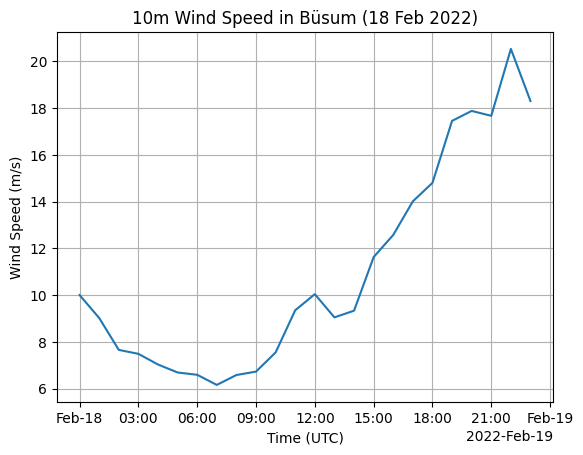

In [3]:
# Load dataset
ds = xr.open_dataset("data/buesum_wind_20220218_19.nc")

# Compute wind speed
u = ds['u10']
v = ds['v10']
wind_speed = np.sqrt(u**2 + v**2)

# Use valid_time instead of time
buesum_point = wind_speed.sel(latitude=54.13, longitude=8.85, method='nearest')

# Slice for February 18 only
buesum_18th = buesum_point.sel(valid_time=slice("2022-02-18", "2022-02-18T23:59"))

# Plot
buesum_18th.plot()
plt.title("10m Wind Speed in Büsum (18 Feb 2022)")
plt.ylabel("Wind Speed (m/s)")
plt.xlabel("Time (UTC)")
plt.grid(True)
plt.show()

## Whole north germany region

In [8]:
# Create CDS API client
c = cdsapi.Client()

# Download ERA5 wind data for February 18, 19, 2022
c.retrieve(
    'reanalysis-era5-single-levels',
    {
        'product_type': 'reanalysis',
        'variable': ['10m_u_component_of_wind', '10m_v_component_of_wind'],
        'year': '2022',
        'month': '02',
        'day': ['18'],
        'time': [f"{h:02d}:00" for h in range(24)],  # hourly
        'format': 'netcdf',
        'area': [53, 7.5, 55, 10.5],  # Bounding box around Büsum (N, W, S, E)
        'grid': [0.25, 0.25],  # 0.25° ERA5 grid
    },
    'data/north_germany_wind_20220218.nc'
)

2025-05-13 15:53:21,096 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-05-13 15:53:21,096 WARNING [2024-06-16T00:00:00] CDS API syntax is changed and some keys or parameter names may have also changed. To avoid requests failing, please use the "Show API request code" tool on the dataset Download Form to check you are using the correct syntax for your API request.
2025-05-13 15:53:21,743 INFO Request ID is 01422fd0-9131-4bf8-aa67-383437482be4
2025-05-13 15:53:21,825 INFO status has been updated to accepted
2025-05-13 15:53:35,522 INFO status has been updated to running
2025-05-13 15:53:43,209 INFO status has been updated to successful


a6fee4b365c022fd99196966f9bd1bff.nc:   0%|          | 0.00/46.8k [00:00<?, ?B/s]

'data/north_germany_wind_20220218.nc'

In [3]:
###### 1.0 resolution ######

# Create CDS API client
c = cdsapi.Client()

# Download ERA5 wind data for February 18, 19, 2022
c.retrieve(
    'reanalysis-era5-single-levels',
    {
        'product_type': 'reanalysis',
        'variable': ['10m_u_component_of_wind', '10m_v_component_of_wind'],
        'year': '2022',
        'month': '02',
        'day': ['18, 19'],
        'time': [f"{h:02d}:00" for h in range(24)],  # hourly
        'format': 'netcdf',
        'area': [53, 7.5, 55, 10.5],  # Bounding box around Büsum (N, W, S, E)
        'grid': [0.1, 0.1],  # 0.25° ERA5 grid
    },
    'data/north_germany_wind_20220218_19_1res.nc'
)

2025-05-28 14:59:53,228 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.


HTTPError: 400 Client Error: Bad Request for url: https://cds.climate.copernicus.eu/api/retrieve/v1/processes/reanalysis-era5-single-levels/execution
invalid request
Invalid integer for day: '18, 19'

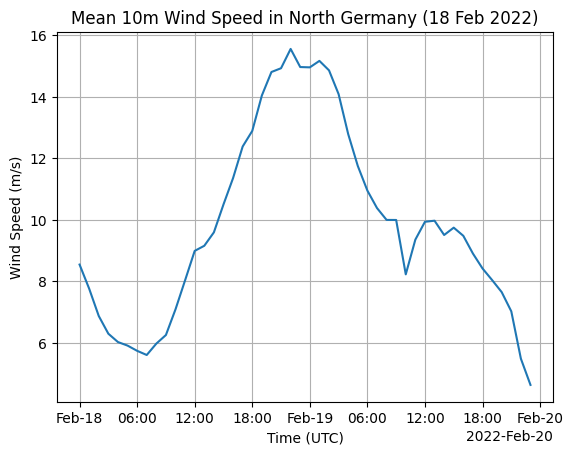

In [8]:
# Load dataset
ds = xr.open_dataset("data/north_germany_wind_20220218_19_1res.nc")

# Compute wind speed magnitude
u = ds['u10']
v = ds['v10']
wind_speed = np.sqrt(u**2 + v**2)

# Compute spatial mean (average over all lat/lon grid points for each time step)
mean_wind = wind_speed.mean(dim=["latitude", "longitude"])

# Plot mean wind speed over time
mean_wind.plot()
plt.title("Mean 10m Wind Speed in North Germany (18 Feb 2022)")
plt.ylabel("Wind Speed (m/s)")
plt.xlabel("Time (UTC)")
plt.grid(True)
plt.show()


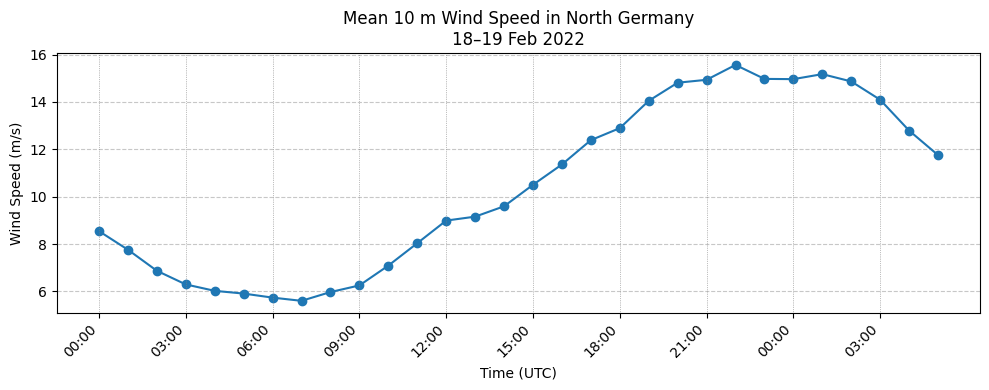

In [13]:
# Load dataset
ds = xr.open_dataset("data/north_germany_wind_20220218_19_1res.nc")

# Compute wind speed magnitude
u = ds['u10']
v = ds['v10']
wind_speed = np.sqrt(u**2 + v**2)

# Compute spatial mean
mean_wind = wind_speed.mean(dim=["latitude", "longitude"])

# 1) Rename the coordinate so we can slice by 'time'
mean_wind = mean_wind.rename({'valid_time': 'time'})

# 2) Slice everything up through 05:00 on Feb 19
mean_wind = mean_wind.sel(time=slice(None, "2022-02-19T05:00"))

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
mean_wind.plot(ax=ax, marker='o', linestyle='-')

ax.set_title("Mean 10 m Wind Speed in North Germany\n18–19 Feb 2022")
ax.set_ylabel("Wind Speed (m/s)")
ax.set_xlabel("Time (UTC)")

# 3) Add a vertical grid & tick every 3 hours
# Find all timestamps at hours divisible by 3
ticks = [t for t in mean_wind['time'].values
         if int(str(t).split("T")[1][:2]) % 3 == 0]

ax.set_xticks(ticks)
ax.set_xticklabels([str(t).split("T")[1][:5] for t in ticks], rotation=45, ha="right")

# Light dotted grid lines at those ticks
for t in ticks:
    ax.axvline(t, color='gray', linestyle=':', linewidth=0.5)

# You still get horizontal grid for y
ax.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()
